In [718]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


df = pd.read_csv('/content/drive/MyDrive/BootCamp Skillnest-Sonda/machine-learning-b2b/data/retail_sales_dataset.csv')

Exploración inicial para entender la estructura del dataset.

In [719]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [720]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [721]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [722]:
df.shape

(1000, 9)

In [723]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## **Identificar valores faltantes, duplicados**

In [724]:
# Eliminar duplicados
antes = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicados eliminados: {antes - len(df):,}')

Duplicados eliminados: 0


## **Tratamiento de nulos**

In [725]:
#Validar Nulos
print(df.isnull().sum())



Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


El dataset viene limpio y no tiene nulos

# Describir las variables y su distribución.

In [726]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## Validando inconsistencias

In [727]:
# Validar que 'Quantity' * 'Price per Unit' = 'Total Amount'
diferencias = df[df['Quantity'] * df['Price per Unit'] != df['Total Amount']]

if not diferencias.empty:
    print(f'Se encontraron {len(diferencias)} discrepancias entre "Quantity" * Price per Unit" y "Total Amount".')
    print(diferencias[['Quantity', 'Price per Unit', 'Total Amount']].head())
else:
    print('No hay diferencias.')

No hay diferencias.


## Validación de contenido por campo

In [728]:
# Analisis para la validacion de los campos categoricos especialemente los campos 'Gender' y 'Product Category' si tienen diferencia en su valores
# por ejemplo en el campo 'Gender' a veces tiene valores como 'Male', 'male', o 'Female', 'Fem', 'female'


columnas_revisar = ['Gender', 'Product Category']

for col in df.select_dtypes(include='object').columns:
  if col in columnas_revisar:
        print('=' * 50)
        print(f'Columna: {col} - Cantidad')
        print(df[col].value_counts().to_string())
        print('=' * 50)

Columna: Gender - Cantidad
Gender
Female    510
Male      490
Columna: Product Category - Cantidad
Product Category
Clothing       351
Electronics    342
Beauty         307


**No existe diferencias en esa columnas**

## **Validando campos y nuevas columnas**

In [729]:
# se creara temporada para mejorar el analisis
def temporada(Date):
    month = Date.month
    day = Date.day

    if (month == 12 and day >= 21) or (month == 1) or (month == 2) or (month == 3 and day < 20):
        return 'Verano'
    elif (month == 3 and day >= 20) or (month == 4) or (month == 5) or (month == 6 and day < 21):
        return 'Otoño'
    elif (month == 6 and day >= 21) or (month == 7) or (month == 8) or (month == 9 and day < 22):
        return 'Invierno'
    else:
        return 'Primavera'

In [730]:
#convertir el campos 'date' de texto a fomato fecha
#se generaron mas campos para tener mas informacion a analizar asociado a fecha

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Año'] = df['Date'].dt.year
df['Mes'] = df['Date'].dt.month
df['Dia'] = df['Date'].dt.day
df['Diasemana'] = df['Date'].dt.dayofweek
df['Semana'] = df['Date'].dt.isocalendar().week
df['Trimestre'] = df['Date'].dt.quarter
df['Temporada'] = df['Date'].apply(temporada)



In [731]:
# Nuevos Campos
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Año                          int32
Mes                          int32
Dia                          int32
Diasemana                    int32
Semana                      UInt32
Trimestre                    int32
Temporada                   object
dtype: object


In [732]:
#Vista de la nueva data
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Año,Mes,Dia,Diasemana,Semana,Trimestre,Temporada
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,24,4,47,4,Primavera
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,27,0,9,1,Verano
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,13,4,2,1,Verano
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,21,6,20,2,Otoño
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,6,5,18,2,Otoño


Matriz de correlacion
                     Age  Quantity  Price per Unit  Total Amount  Diasemana  \
Age             1.000000 -0.023737       -0.038423     -0.060568   0.024743   
Quantity       -0.023737  1.000000        0.017501      0.373707  -0.040846   
Price per Unit -0.038423  0.017501        1.000000      0.851925   0.041272   
Total Amount   -0.060568  0.373707        0.851925      1.000000   0.009262   
Diasemana       0.024743 -0.040846        0.041272      0.009262   1.000000   
Semana          0.002614 -0.010920        0.002760      0.011666  -0.014506   
Trimestre      -0.000837 -0.020411       -0.005834     -0.001605  -0.010157   
Mes            -0.000640 -0.021803       -0.008161     -0.005197  -0.008455   
Año             0.023269 -0.020324        0.020097      0.024714  -0.065555   

                  Semana  Trimestre       Mes       Año  
Age             0.002614  -0.000837 -0.000640  0.023269  
Quantity       -0.010920  -0.020411 -0.021803 -0.020324  
Price per Uni

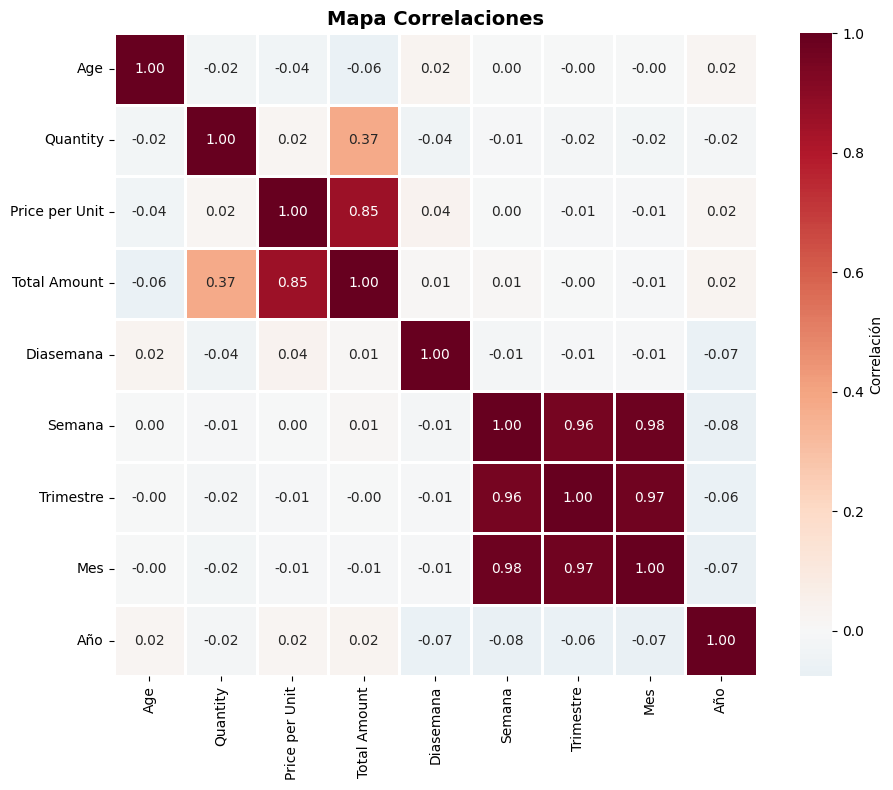

In [733]:
# Matriz y Grafico de correlacion

cols_para_corr = ['Age', 'Quantity', 'Price per Unit', 'Total Amount','Diasemana', 'Semana', 'Trimestre','Mes', 'Año']
corr_matrix = df[cols_para_corr].corr()
print('Matriz de correlacion')
print('='*50)
print(corr_matrix)
print('='*50)
print('Grafico de correlacion')
print('='*50)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=None, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=1, square=True,
            cbar_kws={'label': 'Correlación'})
plt.title('Mapa Correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()



La correlación más fuerte de ve en 'Price per Unit' y 'Quantity', las variables de tiempo agregadas no generaron un cambio aceptable

# **Visualizacion**

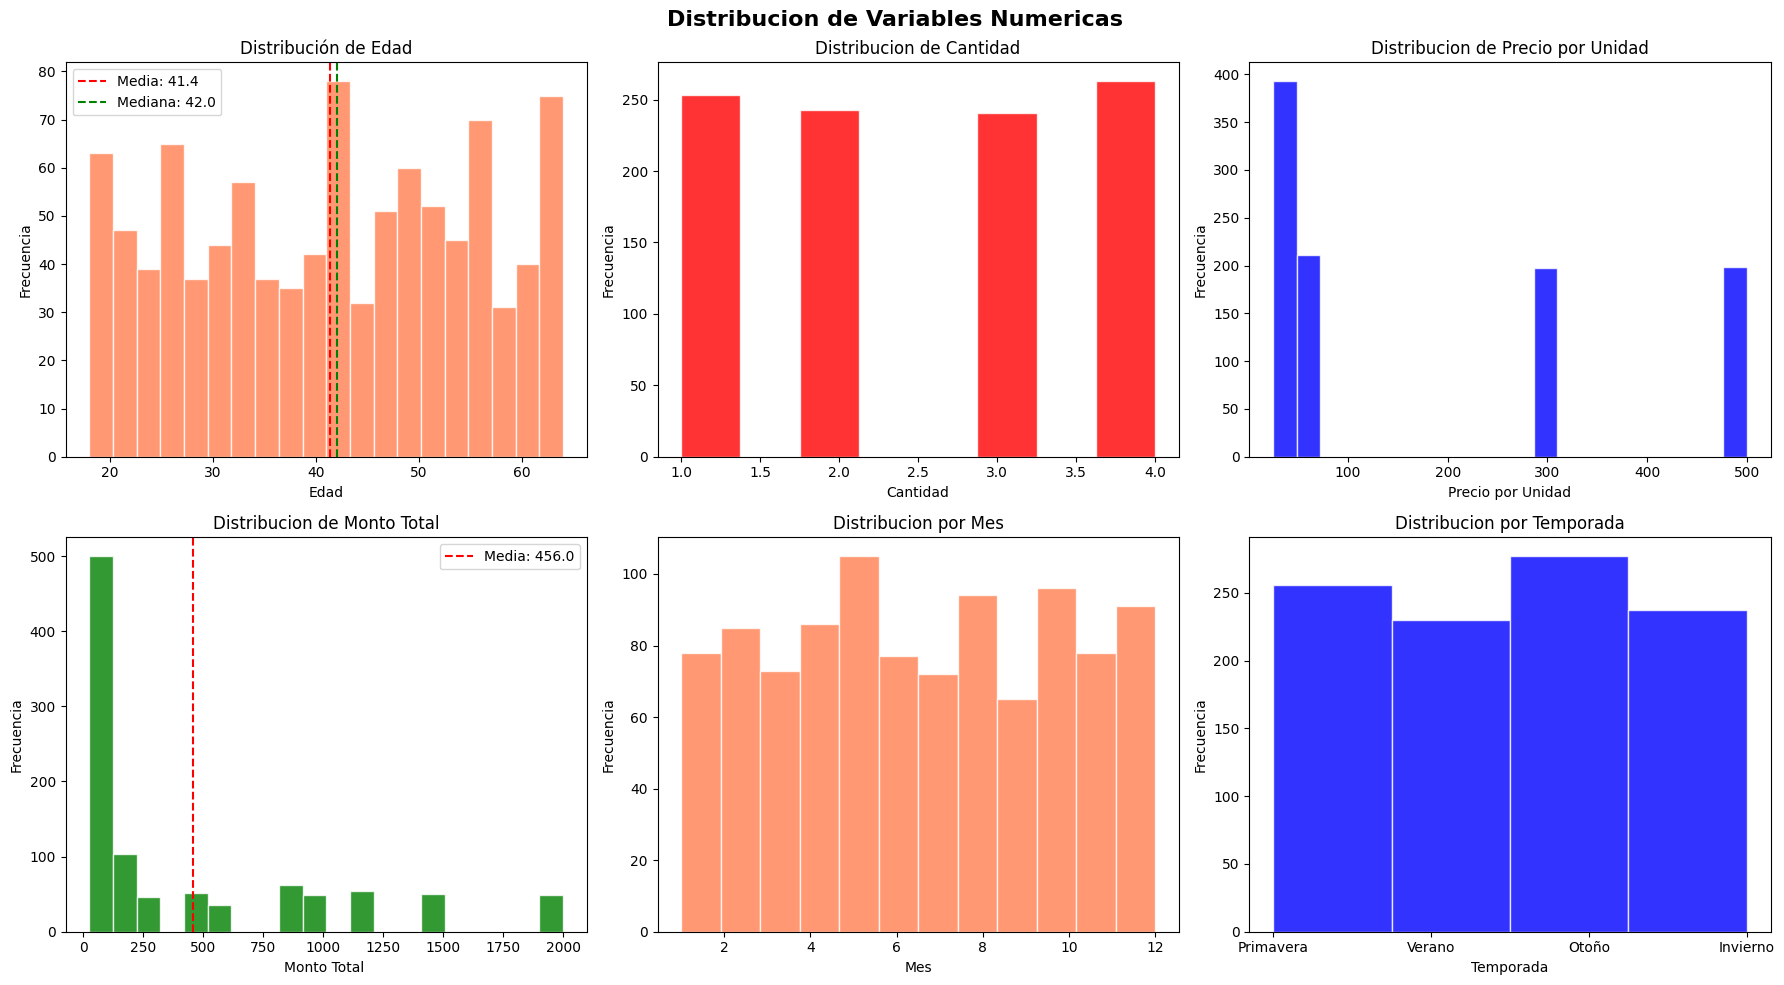

In [734]:
# Histogramas de Variables Numericas


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribucion de Variables Numericas', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['Age'], bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribución de Edad')
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Media: {df['Age'].mean():.1f}')
axes[0, 0].axvline(df['Age'].median(), color='green', linestyle='--', label=f'Mediana: {df['Age'].median():.1f}')
axes[0, 0].legend()

axes[0, 1].hist(df['Quantity'], bins=8, color='red', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Distribucion de Cantidad')
axes[0, 1].set_xlabel('Cantidad')
axes[0, 1].set_ylabel('Frecuencia')

axes[0, 2].hist(df['Price per Unit'], bins=20, color='blue', edgecolor='white', alpha=0.8)
axes[0, 2].set_title('Distribucion de Precio por Unidad')
axes[0, 2].set_xlabel('Precio por Unidad')
axes[0, 2].set_ylabel('Frecuencia')

axes[1, 0].hist(df['Total Amount'], bins=20, color='green', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribucion de Monto Total')
axes[1, 0].set_xlabel('Monto Total ')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['Total Amount'].mean(), color='red', linestyle='--', label=f'Media: {df['Total Amount'].mean():.1f}')
axes[1, 0].legend()

axes[1, 1].hist(df['Mes'], bins=12, color='coral', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Distribucion por Mes')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Frecuencia')

axes[1, 2].hist(df['Temporada'], bins=4, color='blue', edgecolor='white', alpha=0.8)
axes[1, 2].set_title('Distribucion por Temporada')
axes[1, 2].set_xlabel('Temporada')
axes[1, 2].set_ylabel('Frecuencia')

plt.tight_layout()

plt.show()



El histograma por edad muestra que la media es 41.4 y la mediana 42 años.

Por cantidad 4 unidades es la frecuencia que más llevan los clientes.

La gran mayoría de precio unitario está bajo los $100.

La frecuencia del monto total se concentra bajo los $100 y tiene una media de $456.

En mayo se genera la cantidad de ventas y en septiembre en la menor.

otoño es la temporada de mayor venta y Verano la menor.


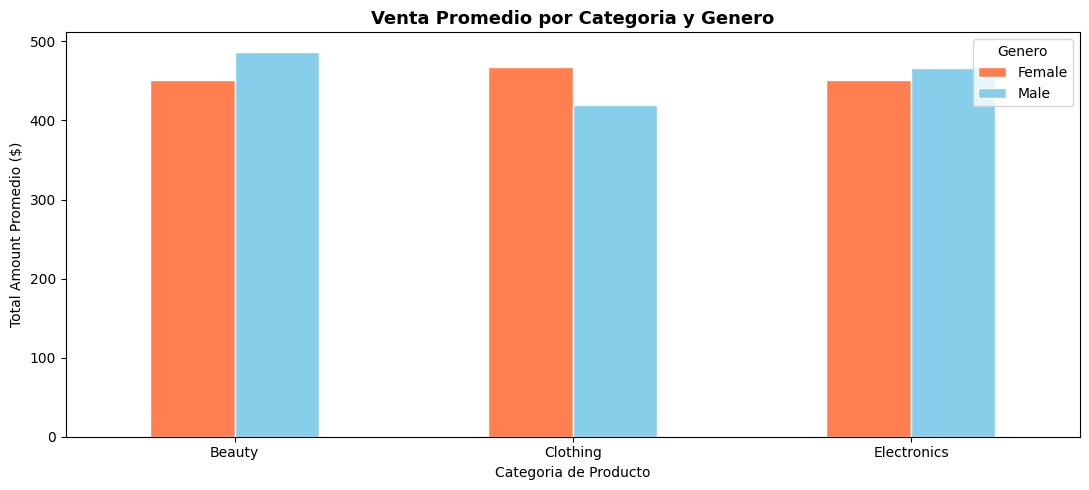

In [735]:
# Venta por Categoria y genero
pivot = df.groupby(['Product Category','Gender'])['Total Amount'].mean().unstack()

ax = pivot.plot(kind='bar', figsize=(11,5), rot=0,
                color=['coral','skyblue'], edgecolor='white')
ax.set_title('Venta Promedio por Categoria y Genero', fontweight='bold', fontsize=13)
ax.set_xlabel('Categoria de Producto')
ax.set_ylabel('Total Amount Promedio ($)')
ax.legend(title='Genero')
plt.tight_layout()
plt.savefig('barras_agrupadas.png', dpi=110, bbox_inches='tight')
plt.show()

Se puede aprecia la venta de categoría por género, donde lo lógico se cumplen que las mujeres compran más ropa y hombres más tecnología pero en este caso también comprar más en belleza, pero puede ser para regalo.

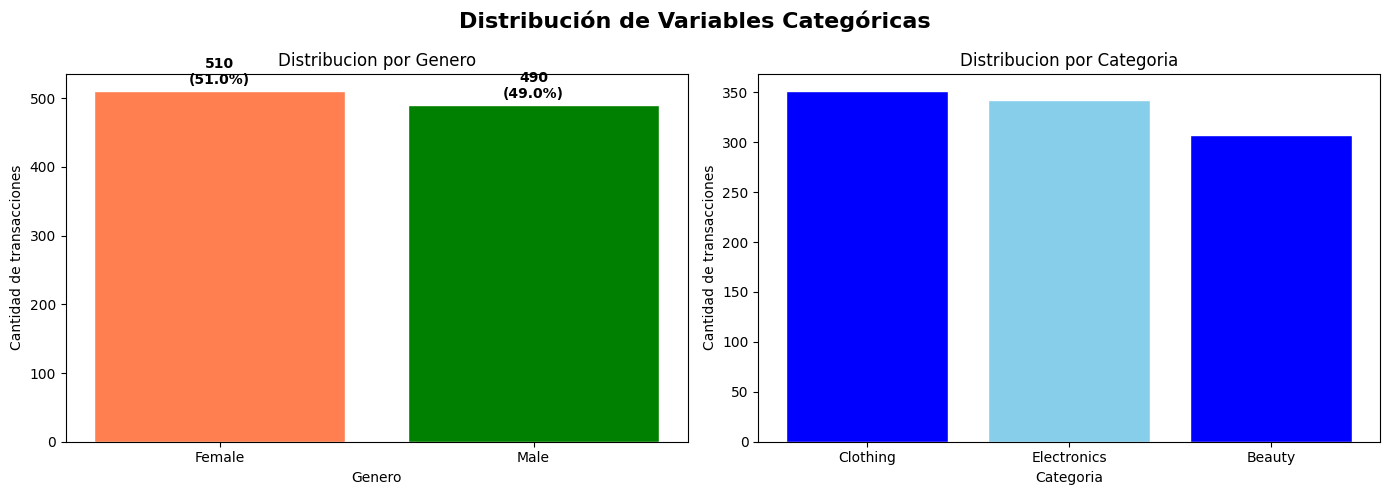

In [736]:
# Graficos de Variables Categoricas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')


gender_counts = df['Gender'].value_counts()
colors_gender = ['coral', 'green']
axes[0].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='white')
axes[0].set_title('Distribucion por Genero')
axes[0].set_xlabel('Genero')
axes[0].set_ylabel('Cantidad de transacciones')
for i, (v, label) in enumerate(zip(gender_counts.values, gender_counts.index)):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')


gender_counts = df['Product Category'].value_counts()
colors_gender = ['blue', 'skyblue']
axes[1].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='white')
axes[1].set_title('Distribucion por Categoria')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Cantidad de transacciones')

plt.tight_layout()
plt.show()



La distribución por genero esta casi idéntica y pero esta llevado por venta de ropa de mujeres. Mientras que tecnología es adquiridas por hombres.

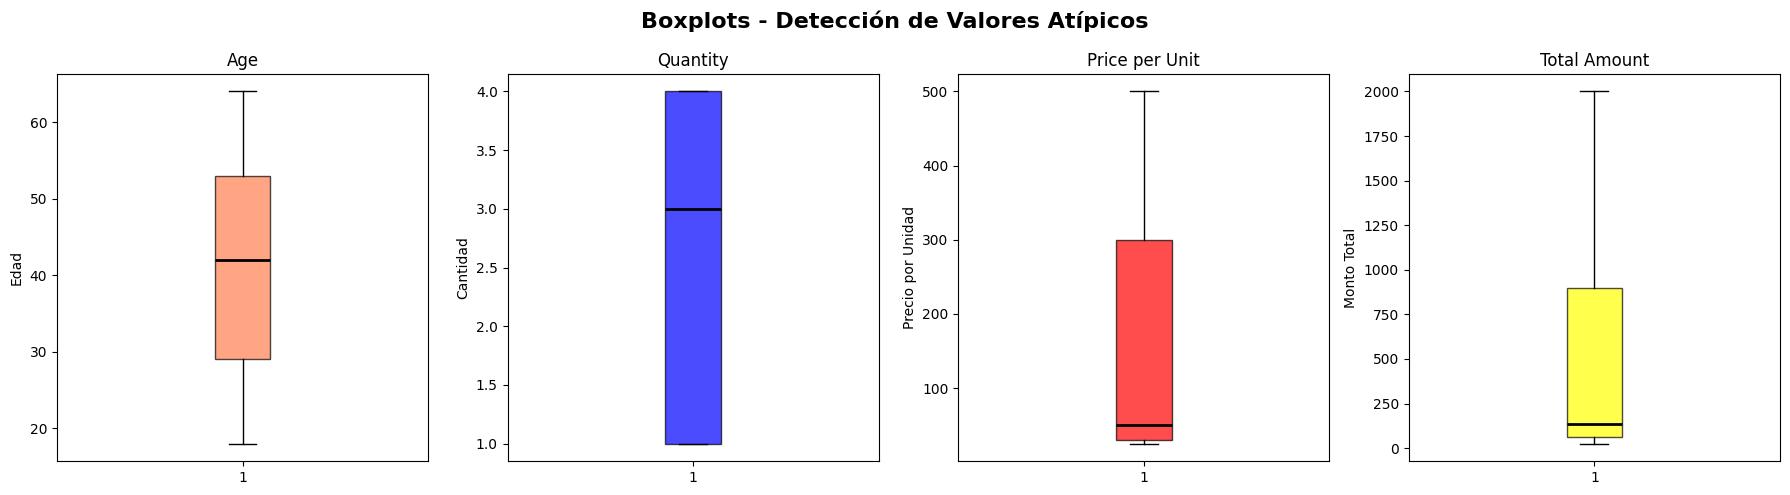

In [737]:
# Analisis graficos de outliers

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Boxplots - Detección de Valores Atípicos', fontsize=16, fontweight='bold')

numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
colors = ['coral', 'blue', 'red', 'yellow']


y_labels_map = {
    'Age': 'Edad',
    'Quantity': 'Cantidad',
    'Price per Unit': 'Precio por Unidad',
    'Total Amount': 'Monto Total'
}

for i, (col, color) in enumerate(zip(numerical_cols, colors)):
    axes[i].boxplot(df[col], patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.7),
                     medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel(y_labels_map.get(col, col))

plt.tight_layout()

plt.show()

En análisis de los Outliers hay una distribución uniforme en el de edad, solo en el del precio por unidad y venta muestra cantidades atípicos y es más que nada por productos más costosos que afectan la venta.


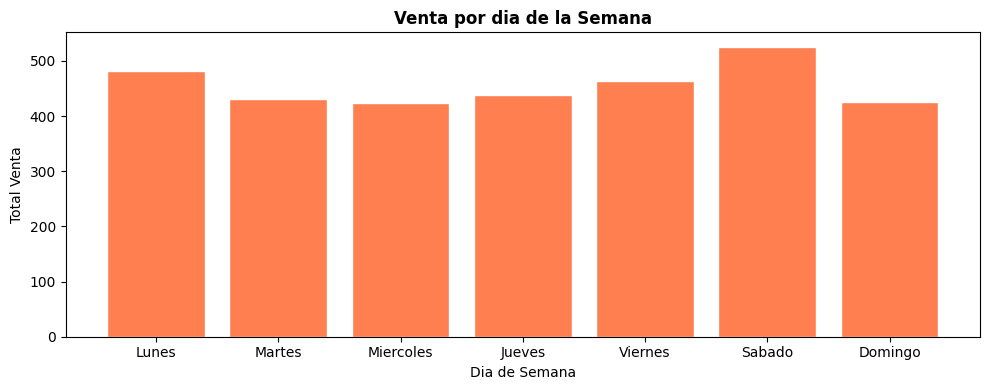

In [738]:
# Ventas promedio por dia de semana
dias = ['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo']
ventas_dia = df.groupby('Diasemana')['Total Amount'].mean()

plt.figure(figsize=(10,4))
bars = plt.bar(dias, ventas_dia.values, color=['coral'],edgecolor='white')
plt.title('Venta por dia de la Semana', fontweight='bold', fontsize=12)
plt.ylabel('Total Venta')
plt.xlabel('Dia de Semana')
plt.tight_layout()
plt.savefig('ventas_dia.png', dpi=110, bbox_inches='tight')
plt.show()

El día sábado se genera la mayor cantidad de venta y los días miércoles y domingo los días con menor venta.

## **Estadísticas descriptivas:**

In [739]:
print('Estadistica Descriptivas:')
desc = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount','Diasemana','Mes']].describe().round(2)
display(desc)

print('Comentarios')
print(f'  • Edad promedio del cliente: {df['Age'].mean():.1f} años')
print(f'  • Rango de edades: {df['Age'].min()} – {df['Age'].max()}')
print(f'  • Cantidad promedio por transacción: {df['Quantity'].mean():.2f} unidades')
print(f'  • Precio unitario: ${df['Price per Unit'].min()} – ${df['Price per Unit'].max()}')
print(f'  • Venta total promedio: ${df['Total Amount'].mean():.2f}')
print(f'  • Mediana de ventas: ${df['Total Amount'].median():.2f}')
print(f'  • Dia de la semana con mas ventas : {df['Diasemana'].max():.0f} ')
print(f'  • Mes del año con mas ventas: {df['Mes'].max():.0f} ')

Estadistica Descriptivas:


,Age,Quantity,Price per Unit,Total Amount,Diasemana,Mes
count,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00
mean,41.39,2.51,179.89,456.0,2.96,6.55
std,13.68,1.13,189.68,560.0,2.02,3.45
min,18.00,1.00,25.00,25.0,0.00,1.00
25%,29.00,1.00,30.00,60.0,1.00,4.00
50%,42.00,3.00,50.00,135.0,3.00,6.00
75%,53.00,4.00,300.00,900.0,5.00,10.00
max,64.00,4.00,500.00,2000.0,6.00,12.00


Comentarios
  • Edad promedio del cliente: 41.4 años
  • Rango de edades: 18 – 64
  • Cantidad promedio por transacción: 2.51 unidades
  • Precio unitario: $25 – $500
  • Venta total promedio: $456.00
  • Mediana de ventas: $135.00
  • Dia de la semana con mas ventas : 6 
  • Mes del año con mas ventas: 12 


# **3.-Implementación de Modelos:**

In [740]:
# Codificando la variables categoricas

le_gender = LabelEncoder()
le_category = LabelEncoder()
le_temporada= LabelEncoder()

df['Gender_enc'] = le_gender.fit_transform(df['Gender'])
df['Category_enc'] = le_category.fit_transform(df['Product Category'])
df['Temporada_enc'] = le_temporada.fit_transform(df['Temporada'])

In [741]:
# Definicion de variables Objetivo, numerica y categoricas
df_modelar= df.copy()
df_modelar.head()

features = ['Age','Price per Unit', 'Diasemana', 'Año', 'Mes', 'Dia', 'Semana', 'Trimestre','Gender_enc','Category_enc','Temporada_enc']
target = 'Total Amount'

y = df_modelar[target] # Assign 'y' before dropping 'Total Amount'
df_modelar.drop(['Transaction ID','Customer ID','Total Amount'],axis=1,inplace= True)

X = df_modelar[features]


## **Division para entrenamiento**

In [742]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

## **Evaluación de Modelos**

In [743]:
# Entrenamiento Decision Tree Regressor

print('Entrenando Decision Tree Regressor....')

dt_SinOpti = DecisionTreeRegressor(random_state=42)

tiempo= time.time()
dt_SinOpti.fit(X_train, y_train)
tiempo_SinOpti_=time.time() -tiempo

y_pred_SinOpti = dt_SinOpti.predict(X_test)

mse_SinOpti  = mean_squared_error(y_test, y_pred_SinOpti)
rmse_SinOpti = np.sqrt(mse_SinOpti)
r2_SinOpti   = r2_score(y_test, y_pred_SinOpti)
mae_SinOpti  = mean_absolute_error(y_test, y_pred_SinOpti)

print(f'\n DecisionTreeRegressor')
print(f'   RMSE: {rmse_SinOpti:.2f}')
print(f'   MAE: {mae_SinOpti:.2f}')
print(f'   R²: {r2_SinOpti:.4f}')


Entrenando Decision Tree Regressor....

 DecisionTreeRegressor
   RMSE: 391.10
   MAE: 223.35
   R²: 0.4528


In [744]:
#Entrenamiento RandomForestRegressor

print('Entrenando RandomForestRegressor....')

rf_SinOpti = RandomForestRegressor(random_state=42)
rf_SinOpti.fit(X_train, y_train)

y_pred_rfOpti_SinOpti = rf_SinOpti.predict(X_test)

mse_rfOpti_SinOpti  = mean_squared_error(y_test, y_pred_rfOpti_SinOpti)
rmse_rfOpti_SinOpti = np.sqrt(mse_rfOpti_SinOpti)
r2_rfOpti_SinOpti   = r2_score(y_test, y_pred_rfOpti_SinOpti)
mae_rfOpti_SinOpti  = mean_absolute_error(y_test, y_pred_rfOpti_SinOpti)

print(f'\n RandomForestRegressor')
print(f'   RMSE: {rmse_rfOpti_SinOpti:.2f}')
print(f'   MAE: {mae_rfOpti_SinOpti:.2f}')
print(f'   R²: {r2_rfOpti_SinOpti:.4f}')


Entrenando RandomForestRegressor....

 RandomForestRegressor
   RMSE: 285.87
   MAE: 172.91
   R²: 0.7076


De los 2 modelos anteriores se tuvo un resultado r2=1, lo que dice que los dos modelos puede predecir de manera óptima y acertada la variable objetivo.

## **Optimización de Modelos**

In [745]:
# Ejecuto Decision Tree Optimizado con GridSearchCV

print('Decision Tree Optimizado con GridSearchCV')

param_grid_dt = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train, y_train)

print(f'\nMejores hiperparametros encontrados:')
for k, v in dt_grid.best_params_.items():
    print(f'  {k}: {v}')


Decision Tree Optimizado con GridSearchCV

Mejores hiperparametros encontrados:
  max_depth: 3
  min_samples_leaf: 1
  min_samples_split: 2


In [746]:
# Capturo e imprimo las metricas
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)

mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt   = r2_score(y_test, y_pred_dt)
mae_dt  = mean_absolute_error(y_test, y_pred_dt)

print(f'\n DecisionTreeRegressor Ootimizado')
print(f'   RMSE: {rmse_dt:.2f}')
print(f'   MAE: {mae_dt:.2f}')
print(f'   R²: {r2_dt:.4f}')



 DecisionTreeRegressor Ootimizado
   RMSE: 278.67
   MAE: 174.05
   R²: 0.7222


In [747]:
# Ejecuto Random Forest Optimizado con GridSearchCV

print('Random Forest con GridSearchCV')

param_grid_rfOpti = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rfOpti,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print(f'\nMejores hiperparametros encontrados:')
for k, v in rf_grid.best_params_.items():
    print(f'  {k}: {v}')


Random Forest con GridSearchCV

Mejores hiperparametros encontrados:
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 200


In [748]:
# Capturo e imprimo las metricas
rf_best = rf_grid.best_estimator_
y_pred_rfOpti = rf_best.predict(X_test)

mse_rfOpti  = mean_squared_error(y_test, y_pred_rfOpti)
rmse_rfOpti = np.sqrt(mse_rfOpti)
r2_rfOpti   = r2_score(y_test, y_pred_rfOpti)
mae_rfOpti  = mean_absolute_error(y_test, y_pred_rfOpti)

print(f'\n DecisionTreeRegressor Optimizado')
print(f'   RMSE: {rmse_rfOpti:.2f}')
print(f'   MAE: {mae_rfOpti:.2f}')
print(f'   R²: {r2_rfOpti:.4f}')



 DecisionTreeRegressor Optimizado
   RMSE: 286.78
   MAE: 177.31
   R²: 0.7058


In [749]:
# Se genera Tabla comparativa
print('='*60)
print('Resultado Final')
print('='*60)
resultados = pd.DataFrame({
    'Modelo': [
        'Decision Tree (base, sin opt.)',
        'Decision Tree (optimizado)',
        'Random Forest (base, sin opt.)',
        'Random Forest (optimizado)'
    ],
    'MAE ($)':  [mae_SinOpti, mae_dt, mae_rfOpti_SinOpti, mae_rfOpti],
    'RMSE ($)': [rmse_SinOpti, rmse_dt, rmse_rfOpti_SinOpti, rmse_rfOpti],
    'MSE':      [mse_SinOpti, mse_dt, mse_rfOpti_SinOpti, mse_rfOpti],
    'R2':       [r2_SinOpti, r2_dt, r2_rfOpti_SinOpti, r2_rfOpti]
}).set_index('Modelo')

resultados = resultados.round(4)
display(resultados)



Resultado Final


,MAE ($),RMSE ($),MSE,R2
Modelo,,,,
"Decision Tree (base, sin opt.)",223.3500,391.1018,152960.5833,0.4528
Decision Tree (optimizado),174.0473,278.6656,77654.5103,0.7222
"Random Forest (base, sin opt.)",172.9090,285.8723,81722.9439,0.7076
Random Forest (optimizado),177.3073,286.7758,82240.3463,0.7058


Solo para el modelo de Random Forest Optimizado, baja las metricas R2 y suben MAE, RMSE y MSE, alejandose del mejor modelo evaluado.  

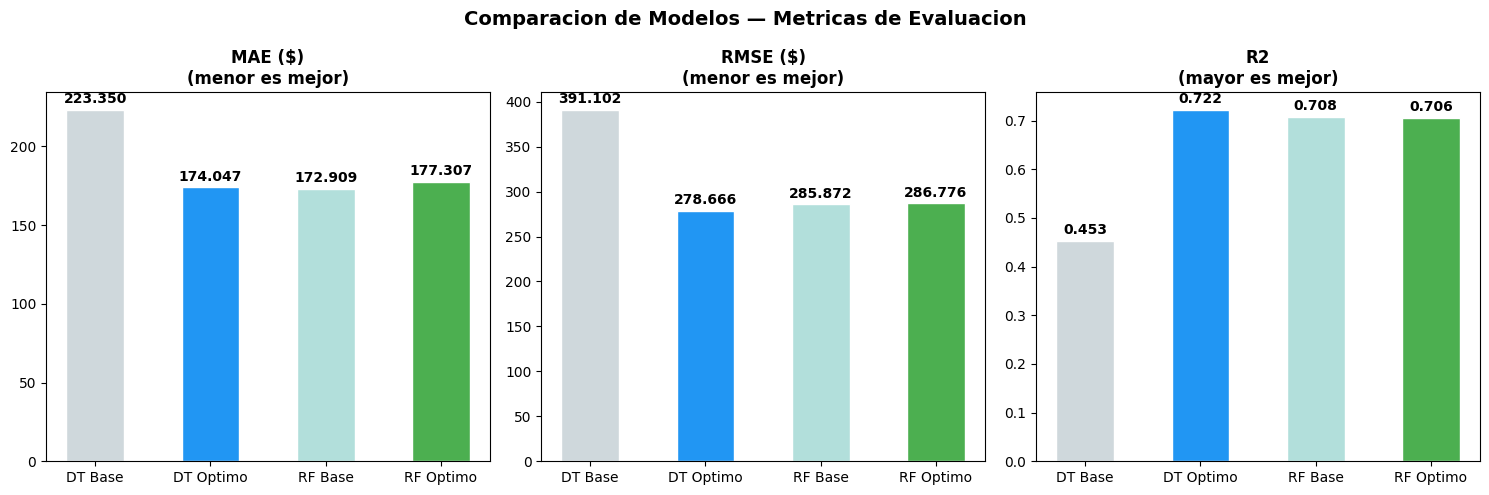

In [750]:
# Grafico de las metricas y su comparacion
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparacion de Modelos — Metricas de Evaluacion', fontsize=14, fontweight='bold')

modelos_labels = ['DT Base', 'DT Optimo', 'RF Base', 'RF Optimo']
colores_mod = ['#CFD8DC', '#2196F3', '#B2DFDB', '#4CAF50']

metricas = [
    ('MAE ($)', [mae_SinOpti, mae_dt, mae_rfOpti_SinOpti, mae_rfOpti], 'menor es mejor'),
    ('RMSE ($)', [rmse_SinOpti, rmse_dt, rmse_rfOpti_SinOpti, rmse_rfOpti], 'menor es mejor'),
    ('R2', [r2_SinOpti, r2_dt, r2_rfOpti_SinOpti, r2_rfOpti], 'mayor es mejor'),
]

for ax, (nombre, valores, nota) in zip(axes, metricas):
    bars = ax.bar(modelos_labels, valores, color=colores_mod, edgecolor='white', width=0.5)
    ax.set_title(f'{nombre}\n({nota})', fontweight='bold')
    if nombre == 'R²':
        ax.set_ylim(0, 1.15)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + ax.get_ylim()[1]*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

plt.show()

## **Comparación de Rendimiento:**

Este Data set tiene una relación directa entre las variables predictoras y variables objetivo. Venta total = Precio Unitario * Unidad. Por lo que hubo que sacar la variable Quantity,  porque era parte de fórmula de la variable objetivo y el modelo aprendía enseguida de la relacion P*Q.

Análisis de las métricas:
Mae: Mientras menor sea el MAE, mejor es el modelo, Random Forest Base (172.91)
RMSE: Mientras menor sea el RMSE, mejor Decision Tree Optimizado (278.67)
R2:Mientras mayor sea R2, mejor es el modelo.Decision Tree Optimizado (0.722)

La optimización de Decision Tree redujo significativamente el error y mejoro en un 62% el valor de R2

Por el contrario La optimización de Random Forest las variables MAE y RSME aumentaron y r2 bajo ligeramente, esto indica que el modelo base ya estaba cerca del óptimo y GridSearchCV no encontró hiperparámetros superiores.

Los 2 modelos evaluados Tree Regressor y Random Forest Regressor puede capturar la relación con alta precisión. Ambos modelos tienen un r2 muy alto.

La gran diferencia se produce al crecer la cantidad de árboles que se evalúan en Random Forestp puede bajar el r2 como en este caso.

Por ser un dataset tan pequeño los 2 cubren el objetivo, solo Random Forest los cubre en mayor tiempo, por lo que  Tree Regressor es el elegido a resolverlo en menor tiempo.